# Lab 2.2 - Train the Same Problem With TensorFlow/Keras (MNIST)

This notebook has `# TODO` markers (TODO 1-7). Work through them in order -
later cells depend on earlier ones (e.g. the hyperparameter sweep in Step 2
reuses the `build_model()` function you write in Step 1).

MNIST downloads automatically the first time you run this notebook (via
`tf.keras.datasets.mnist`) - no manual download needed, but you do need a
working internet connection the first time.

In [1]:
import time
import os
import numpy as np
import tensorflow as tf
import tf_keras
import matplotlib.pyplot as plt

tf.random.set_seed(10)
np.random.seed(10)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 1 - Build and train a small CNN

Architecture (matches the lab diagram):

`Input 28x28x1 -> Conv2D(8, 3x3, ReLU) -> MaxPool(2x2) -> Conv2D(16, 3x3, ReLU) -> MaxPool(2x2) -> Flatten -> Dense(32, ReLU) -> Dense(10, Softmax)`

Kept small on purpose - this exact model gets quantized (2.3) and pruned +
deployed to the Pico (2.4).

Data loading and normalization are provided for you below.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize to [0, 1] and add the channel dimension Conv2D expects
x_train = (x_train / 255.0).astype("float32")[..., np.newaxis]
x_test  = (x_test  / 255.0).astype("float32")[..., np.newaxis]

print("x_train:", x_train.shape, " x_test:", x_test.shape)

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 31s 3us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 41s 4us/step

  196608/11490434 ━━━━━━━━━━━━━━━━━━━━ 20s 2us/step

  262144/11490434 ━━━━━━━━━━━━━━━━━━━━ 17s 2us/step

...

 7045120/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 8503296/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10502144/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


x_train: (60000, 28, 28, 1)  x_test: (10000, 28, 28, 1)


**TODO 1:** Complete `build_model()`. It should return a `tf_keras`
`Sequential` model with two conv+pool blocks feeding a small dense head,
matching the architecture above. The function takes some hyperparameters as
arguments - you'll reuse this same function for the experiments in Step 2,
so make sure each argument actually controls the thing its name says it does.

**Use `tf_keras`, not `tf.keras`, for every layer and the `Sequential` call.**
This is deliberate: `tf_keras` is the standalone legacy-Keras package (as
opposed to the Keras 3 that `tf.keras` points to by default). Building with
it now means Lab 2.3 can load this exact model directly for quantization,
including quantization-aware training, with no conversion step in between.

A couple of other things worth knowing before you write this:
- If `dropout > 0`, add a `Dropout` layer after the dense layer; if it's 0,
  skip it entirely (don't add a no-op layer in its place - an empty
  `tf_keras.layers.Layer()` doesn't have a working `call()` and will crash
  training).
- The output layer is always 10 units with softmax, regardless of the
  `activation` argument (that argument only controls the *hidden* layers).

In [3]:
def build_model(num_filters1=8, num_filters2=16, dense_units=32,
                 activation="relu", dropout=0.0, num_conv_blocks=2):
    # TODO 1: build and return the Sequential model described above, using
    # tf_keras (not tf.keras) for every layer.
    L = tf_keras.layers
    layers = [L.Conv2D(num_filters1, (3, 3), activation=activation, input_shape=(28, 28, 1)),
              L.MaxPooling2D((2, 2))]
    # num_conv_blocks is for the "number of layers" experiment, 2 = the lab architecture
    for _ in range(num_conv_blocks - 1):
        layers += [L.Conv2D(num_filters2, (3, 3), activation=activation), L.MaxPooling2D((2, 2))]
    layers += [L.Flatten(), L.Dense(dense_units, activation=activation)]
    if dropout > 0:
        layers.append(L.Dropout(dropout))
    layers.append(L.Dense(10, activation="softmax"))
    return tf_keras.models.Sequential(layers)

model = build_model()
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d (Conv2D)             (None, 26, 26, 8)         80        


 max_pooling2d (MaxPooling2  (None, 13, 13, 8)         0         


...

 dense_1 (Dense)             (None, 10)                330       


Total params: 14410 (56.29 KB)


Trainable params: 14410 (56.29 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


**TODO 2:** Compile and train the model.
- Optimizer: `"adam"`
- Loss: sparse categorical crossentropy (labels are integers 0-9, not one-hot)
- Metric: accuracy
- Train for 5 epochs, batch size 64, using `x_test`/`y_test` as validation data.

In [4]:
# TODO 2: compile and fit the model, capturing the returned History object
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(x_train, y_train, epochs=5, batch_size=64,
                    validation_data=(x_test, y_test), verbose=2)

Epoch 1/5


W0000 00:00:1791352799.639122       7 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


938/938 - 3s - loss: 0.3153 - accuracy: 0.9083 - val_loss: 0.0979 - val_accuracy: 0.9702 - 3s/epoch - 3ms/step


Epoch 2/5


938/938 - 2s - loss: 0.0970 - accuracy: 0.9704 - val_loss: 0.0762 - val_accuracy: 0.9770 - 2s/epoch - 3ms/step


...

938/938 - 2s - loss: 0.0730 - accuracy: 0.9775 - val_loss: 0.0546 - val_accuracy: 0.9817 - 2s/epoch - 2ms/step


Epoch 4/5


938/938 - 2s - loss: 0.0589 - accuracy: 0.9818 - val_loss: 0.0524 - val_accuracy: 0.9824 - 2s/epoch - 3ms/step


Epoch 5/5


938/938 - 2s - loss: 0.0497 - accuracy: 0.9843 - val_loss: 0.0414 - val_accuracy: 0.9869 - 2s/epoch - 2ms/step


Baseline model -- test accuracy: 0.9869, test loss: 0.0414


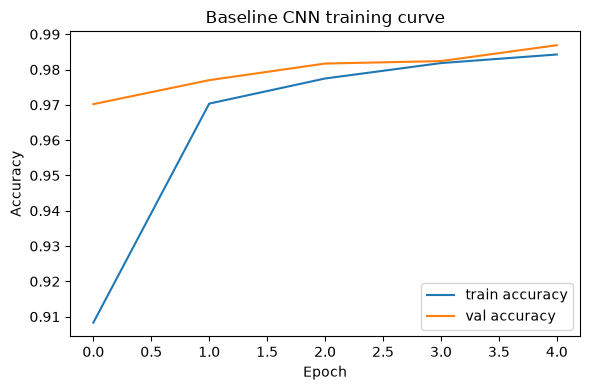

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline model -- test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN training curve")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_training_curve.png", dpi=110)
plt.show()

## Step 2 - Experiment with training parameters

Try changing each of the following, one at a time, and note the effect on
accuracy, training time, and model size:

- Learning rate
- Optimizer (SGD vs Adam vs RMSprop)
- Number of epochs
- Batch size
- Activation functions
- Number of filters/neurons per layer
- Dropout
- Number of layers

**TODO 3:** Complete `run_experiment()` below (build, train, and evaluate a
model, timing the training run and counting its trainable parameters), then
add your own entries to the `results` list - at least one experiment per
bullet point above. Reuse `build_model()` and `run_experiment()`; don't
rewrite the training loop by hand for each one.

In [6]:
import pandas as pd

def count_params(m):
    return int(np.sum([tf_keras.backend.count_params(w) for w in m.trainable_weights]))

def run_experiment(name, optimizer, epochs=3, batch_size=64, activation="relu",
                    num_filters1=8, num_filters2=16, dense_units=32, dropout=0.0,
                    num_conv_blocks=2):
    # TODO 3a: build the model with the given hyperparameters
    m = build_model(num_filters1, num_filters2, dense_units, activation, dropout, num_conv_blocks)

    # TODO 3b: compile it (same loss/metric as Step 1) with the given optimizer
    m.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # TODO 3c: time a call to m.fit() with the given epochs/batch_size (verbose=0)
    start = time.time()
    m.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    elapsed = time.time() - start

    # TODO 3d: evaluate on the test set and count trainable params
    acc = m.evaluate(x_test, y_test, verbose=0)[1]
    n_params = count_params(m)

    return {
        "experiment": name,
        "test_accuracy": round(acc, 4),
        "train_time_sec": round(elapsed, 1),
        "trainable_params": n_params,
    }

# TODO 3e: add at least one run_experiment(...) call per bullet point above
# each run changes one thing compared to the baseline
results = []
results.append(run_experiment("baseline (adam, lr=default)", optimizer="adam"))
results.append(run_experiment("learning rate 0.01", optimizer=tf_keras.optimizers.Adam(learning_rate=0.01)))
results.append(run_experiment("optimizer sgd", optimizer="sgd"))
results.append(run_experiment("optimizer rmsprop", optimizer="rmsprop"))
results.append(run_experiment("10 epochs", optimizer="adam", epochs=10))
results.append(run_experiment("batch size 512", optimizer="adam", batch_size=512))
results.append(run_experiment("sigmoid activation", optimizer="adam", activation="sigmoid"))
results.append(run_experiment("32/64 filters, 128 dense", optimizer="adam",
                              num_filters1=32, num_filters2=64, dense_units=128))
results.append(run_experiment("dropout 0.25", optimizer="adam", dropout=0.25))
results.append(run_experiment("3 conv blocks", optimizer="adam", num_conv_blocks=3))

results_df = pd.DataFrame(results)
results_df

W0000 00:00:1791352812.213626       7 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


W0000 00:00:1791352819.832923       7 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


W0000 00:00:1791352827.385831       7 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


W0000 00:00:1791352833.781054       7 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


,experiment,test_accuracy,train_time_sec,trainable_params
0,"baseline (adam, lr=default)",0.9809,7.3,14410
1,learning rate 0.01,0.9823,7.2,14410
2,optimizer sgd,0.9530,6.1,14410
3,optimizer rmsprop,0.9760,6.7,14410
4,10 epochs,0.9873,23.2,14410
5,batch size 512,0.9621,2.4,14410
6,sigmoid activation,0.9544,8.0,14410
7,"32/64 filters, 128 dense",0.9900,15.3,225034
8,dropout 0.25,0.9777,7.2,14410
9,3 conv blocks,0.9588,7.5,4442


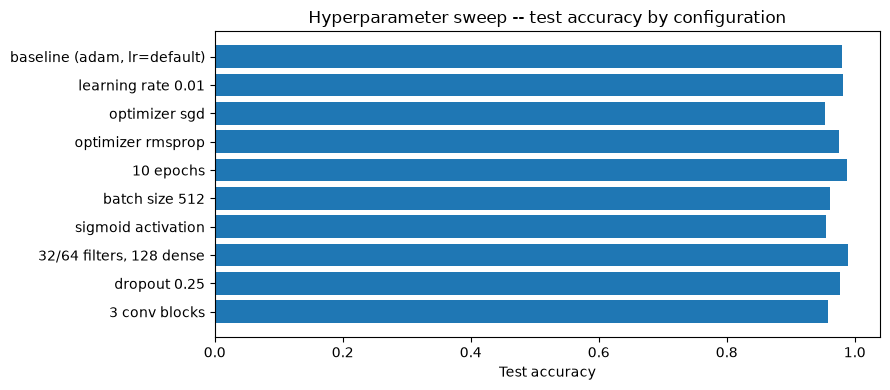

Best configuration in this sweep:
experiment          32/64 filters, 128 dense
test_accuracy                           0.99
train_time_sec                          15.3
trainable_params                      225034
Name: 7, dtype: object


In [7]:
plt.figure(figsize=(9, 4))
plt.barh(results_df["experiment"], results_df["test_accuracy"])
plt.xlabel("Test accuracy")
plt.title("Hyperparameter sweep -- test accuracy by configuration")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("hyperparameter_sweep.png", dpi=110)
plt.show()

best_row = results_df.loc[results_df["test_accuracy"].idxmax()]
print("Best configuration in this sweep:")
print(best_row)

## Step 3 - Create and test your own dataset

1. Draw all 10 digits (phone app, or on paper + photo).
2. Save them into the `my_digits/` folder as `digit_0.png`, `digit_1.png`,
   ... `digit_9.png` (one file per digit, filename matches the digit drawn).
3. Complete the preprocessing function below so your photos match MNIST's
   format **exactly**:
   - Convert to grayscale.
   - Resize to 28x28.
   - MNIST digits are **white strokes on a black background** - a normal
     photo of pen-on-paper is the opposite (dark strokes on a light
     background), so you'll need to invert it.
   - Normalize to [0, 1].

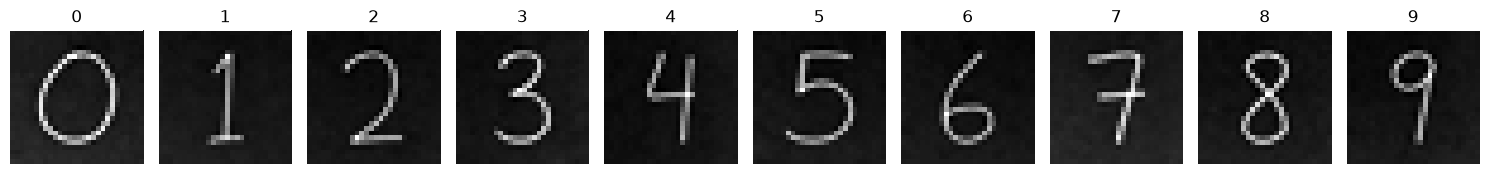

In [8]:
from PIL import Image

def load_and_preprocess_digit(path):
    # TODO 4: grayscale -> resize to 28x28 -> invert -> normalize to [0,1]
    img = Image.open(path).convert("L").resize((28, 28))
    # photo is dark ink on light paper, mnist is white on black
    arr = (255 - np.asarray(img, dtype="float32")) / 255.0
    return arr

digits_dir = "my_digits"
my_x, my_y = [], []
for digit in range(10):
    path = os.path.join(digits_dir, f"digit_{digit}.png")
    my_x.append(load_and_preprocess_digit(path))
    my_y.append(digit)

my_x = np.array(my_x)[..., np.newaxis]
my_y = np.array(my_y)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(my_x[i, :, :, 0], cmap="gray")
    ax.set_title(str(my_y[i]))
    ax.axis("off")
plt.tight_layout()
plt.savefig("my_digits_preview.png", dpi=110)
plt.show()

**TODO 5:** Evaluate your trained model on your own digits and print
whether each prediction was correct. Expect worse accuracy than on MNIST's
test set - be ready to explain why (distribution shift: your handwriting,
pen, and camera/scanner don't match how MNIST's ~70,000 images were
collected).

In [9]:
# TODO 5: evaluate model on (my_x, my_y), then print true vs. predicted
# digit for each of the 10 images, with an OK/WRONG marker
my_pred = model.predict(my_x, verbose=0).argmax(axis=1)
for true, pred in zip(my_y, my_pred):
    print(f"true {true}  predicted {pred}  {'OK' if true == pred else 'WRONG'}")
my_acc = float(np.mean(my_pred == my_y))
print(f"Accuracy on my own digits: {my_acc:.4f}  (MNIST test accuracy was {test_acc:.4f})")

true 0  predicted 0  OK
true 1  predicted 1  OK
true 2  predicted 2  OK
true 3  predicted 3  OK
true 4  predicted 4  OK
true 5  predicted 5  OK
true 6  predicted 6  OK
true 7  predicted 8  WRONG
true 8  predicted 8  OK
true 9  predicted 7  WRONG
Accuracy on my own digits: 0.8000  (MNIST test accuracy was 0.9869)


## Step 4 - Save the trained model

**TODO 6:** Save the model in both `.h5` and `SavedModel` format
(`model.save("mnist_cnn.h5")` and `model.save("mnist_cnn_savedmodel")` - a
path with no recognized extension saves as `SavedModel`). You'll load this
exact model again in Lab 2.3, so keep both files/folders safe.

In [10]:
# TODO 6: save the model as mnist_cnn.h5 and as a SavedModel export
model.save("mnist_cnn.h5")
model.save("mnist_cnn_savedmodel")

/opt/venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


INFO:tensorflow:Assets written to: mnist_cnn_savedmodel/assets


INFO:tensorflow:Assets written to: mnist_cnn_savedmodel/assets


## Discussion Topics

Answer in a few sentences each:

1. Which single hyperparameter gave you the biggest accuracy gain (or loss)?
2. Where did your own handwritten digits fail, and why do you think that is?
3. What's the tradeoff between model size and accuracy in your experiments?

### Answers

1. The biggest gain came from the number of filters/neurons: 32/64 filters and 128 dense got 99.0 % vs
   98.1 % for the baseline (3 epochs each). The biggest loss came from the optimizer: plain SGD got 95.3 %,
   it learns too slowly for 3 epochs. Sigmoid (95.4 %), 3 conv blocks (95.9 %) and batch 512 (96.2 %) were
   also clearly worse. Training for 10 epochs (98.7 %) was the best change that does not make the model bigger.

2. 8/10 on my digits vs 98.7 % on the MNIST test set. The 7 was predicted as 8: my 7 has a crossbar, which
   MNIST 7s almost never have, so the middle looks like an 8. The 9 was predicted as 7: small loop and a long
   straight tail. On top of that the inputs just look different from MNIST: thin strokes, the paper does not
   go fully black after inverting, and the digits are not scaled and centred the way MNIST digits are.

3. The bigger model has 15.6x the parameters (225 034 vs 14 410) for +0.9 points. 3 conv blocks has 3.2x
   fewer (4 442) but loses 2.2 points. Most of the baseline's weights (12 832 of 14 410) are in the first dense
   layer, so the conv part is cheap. Accuracy gains get small fast while size grows a lot, so for the Pico the
   baseline is a good compromise.